In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive/


Once Google Drive is mounted, you can access your files. For example, if you have a CSV file named `my_data.csv` in the root of your Google Drive, you can load it using pandas like this:

```python
import pandas as pd

# Adjust the path to your specific file
file_path = '/content/drive/MyDrive/my_data.csv'
df = pd.read_csv(file_path)
display(df.head())
```

Remember to replace `my_data.csv` with the actual name and path of your file within Google Drive.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("/content/drive/MyDrive/Portfolio/Data Analyst/Superstore Dataset/SampleSuperstore.csv")

df

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


# DATA CLEANING

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


## CEK DATA DUPLIKAT

In [10]:
df.duplicated().sum()

np.int64(17)

In [15]:
df = df.drop_duplicates()

In [16]:
print(f"Jumlah duplikat sekarang: {df.duplicated().sum()}")
print(f"Total baris data sekarang:{len(df)}")

Jumlah duplikat sekarang: 0
Total baris data sekarang:9977


## CEK DATA KOSONG

In [18]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


Tidak ada data yang kosong pada tabel tersebut

# ANALISIS SEDERHANA

### Total penjualan tiap kategori

In [19]:
insight_kategori = df.groupby('Category')['Sales'].sum()
print(insight_kategori)

Category
Furniture          741306.3133
Office Supplies    718735.2440
Technology         836154.0330
Name: Sales, dtype: float64


### Kota dengan profit terbesar

In [25]:
profit_terbesar = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(5)
print(profit_terbesar)

City
New York City    62013.8973
Los Angeles      30431.4267
Seattle          29121.6825
San Francisco    17466.1186
Detroit          13146.6935
Name: Profit, dtype: float64


### Kota dengan profit yang paling kecil

In [23]:
profit_terkecil = df.groupby('City')['Profit'].sum().sort_values().head(5)
print(profit_terkecil)

City
Philadelphia   -13843.2106
Houston        -10175.1755
San Antonio     -7299.0502
Lancaster       -7239.0684
Chicago         -6648.3318
Name: Profit, dtype: float64


### Profit per kategori

In [30]:
profit_per_kategori = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(profit_per_kategori)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


# VISUALISASI

### Profit per Kategori

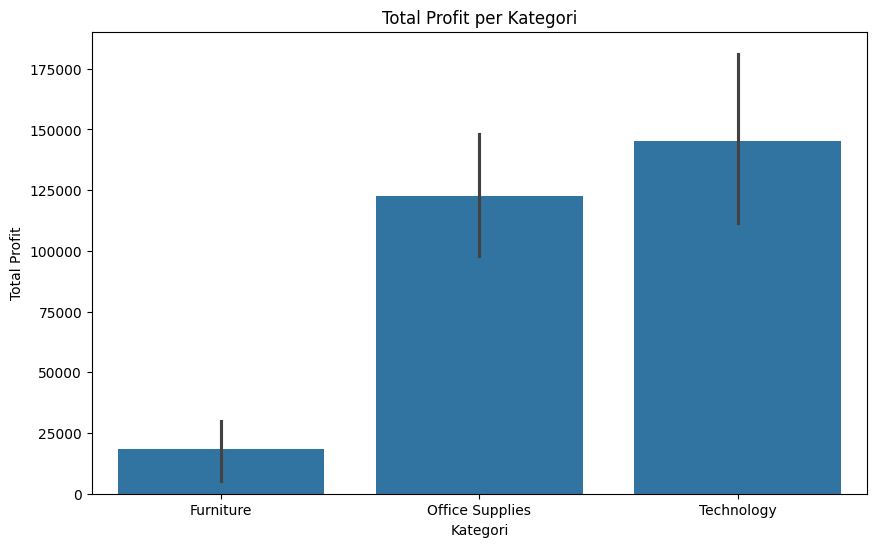

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(x='Category', y='Profit', data=df, estimator=sum)
plt.title('Total Profit per Kategori')
plt.xlabel('Kategori')
plt.ylabel('Total Profit')
plt.show()

### Profit per Kota
5 teratas dan 5 terendah

In [39]:
city_profit = df.groupby('City')['Profit'].sum().reset_index()
top_5_cicties = city_profit.sort_values(by='Profit', ascending=False).head(5)
bottom_5_cities = city_profit.sort_values(by='Profit', ascending=True).head(5)
extreme_cities = pd.concat([top_5_cities, bottom_5_cities])

/tmp/ipykernel_406/2733781330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profit', y='City', data=extreme_cities, palette=colors)


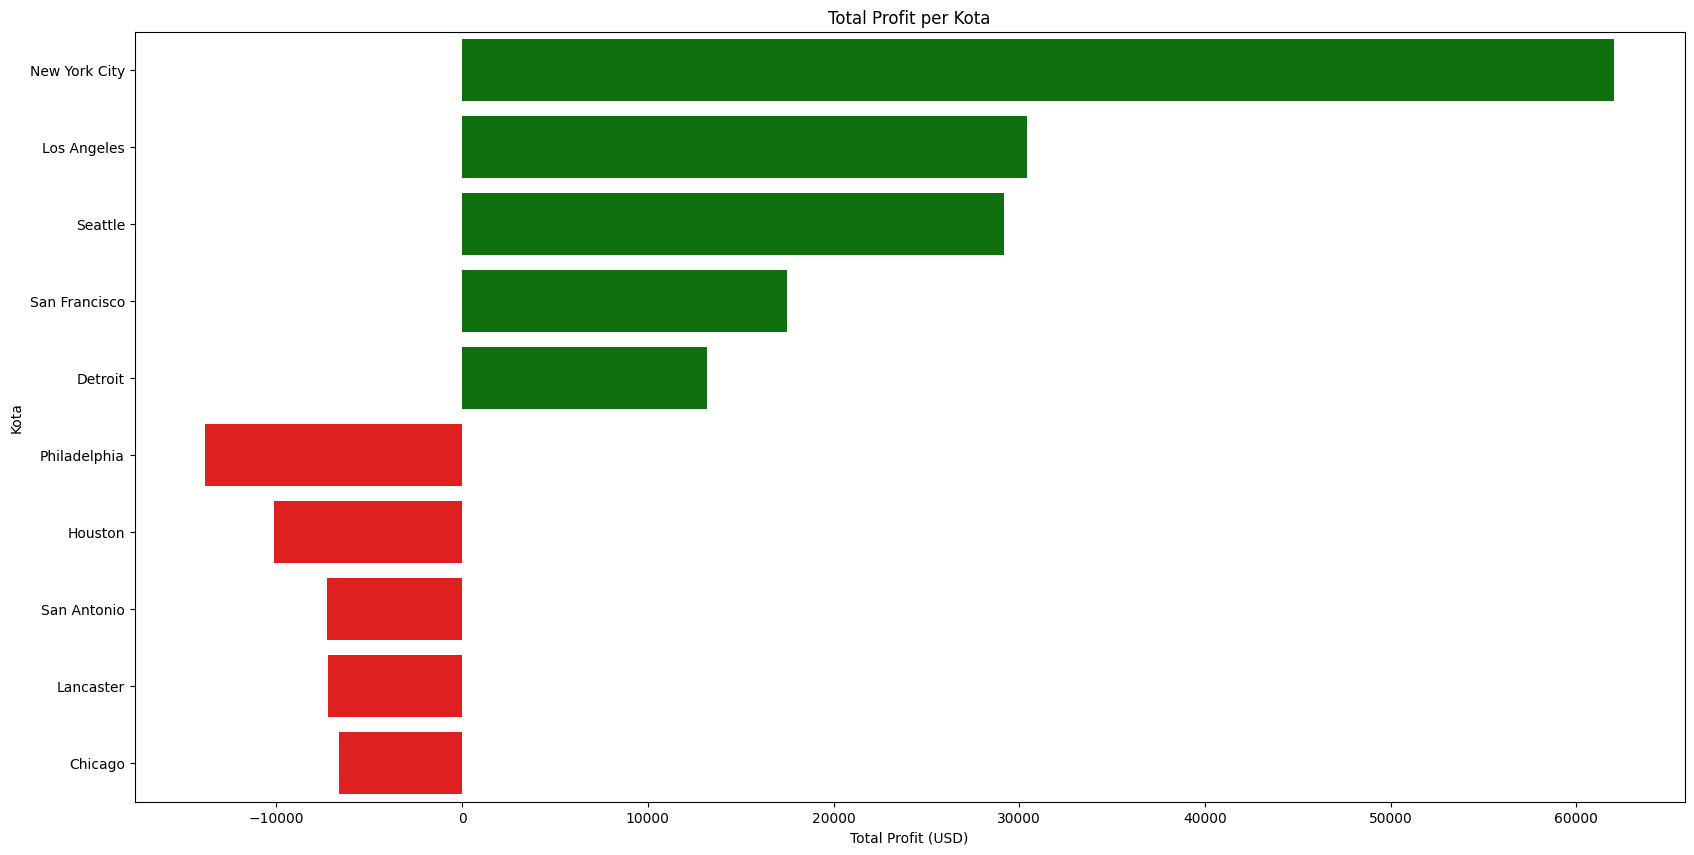

In [40]:
plt.figure(figsize=(20,10))
colors = ['green']*5 + ['red']*5
sns.barplot(x='Profit', y='City', data=extreme_cities, palette=colors)
plt.title('Total Profit per Kota')
plt.xlabel('Total Profit (USD)')
plt.ylabel('Kota')
plt.show()

# DRILL-DOWN ANALYSIS

### KATEGORI PRODUK DENGAN PROFIT TERENDAH DI TIAP KOTA

In [48]:
list_kota_rugi = bottom_5_cities['City'].tolist()
df_rugi = df[df['City'].isin(list_kota_rugi)]

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
23,Second Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Chairs,71.3720,2,0.30,-1.0196
27,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Bookcases,3083.4300,7,0.50,-1665.0522
28,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Office Supplies,Binders,9.6180,2,0.70,-7.0532
29,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Furnishings,124.2000,3,0.20,15.5250
30,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Office Supplies,Envelopes,3.2640,2,0.20,1.1016
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9946,Standard Class,Corporate,United States,Philadelphia,Pennsylvania,19120,East,Technology,Accessories,151.2000,3,0.20,32.1300
9961,First Class,Home Office,United States,Houston,Texas,77041,Central,Office Supplies,Paper,65.5840,2,0.20,23.7742
9962,First Class,Home Office,United States,Houston,Texas,77041,Central,Furniture,Bookcases,383.4656,4,0.32,-67.6704
9963,Same Day,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Office Supplies,Paper,10.3680,2,0.20,3.6288


In [45]:
kategori_rugi = df_rugi.groupby('Category')['Profit'].sum().sort_values()

print("Profit per Kategori di Kota_Kota Merah:")
print(kategori_rugi)

Profit per Kategori di Kota_Kota Merah:
Category
Office Supplies   -24207.5776
Furniture         -14211.6445
Technology         -6764.7812
Name: Profit, dtype: float64


/tmp/ipykernel_406/1480215986.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kategori_rugi.values, y=kategori_rugi.index, palette='OrRd')


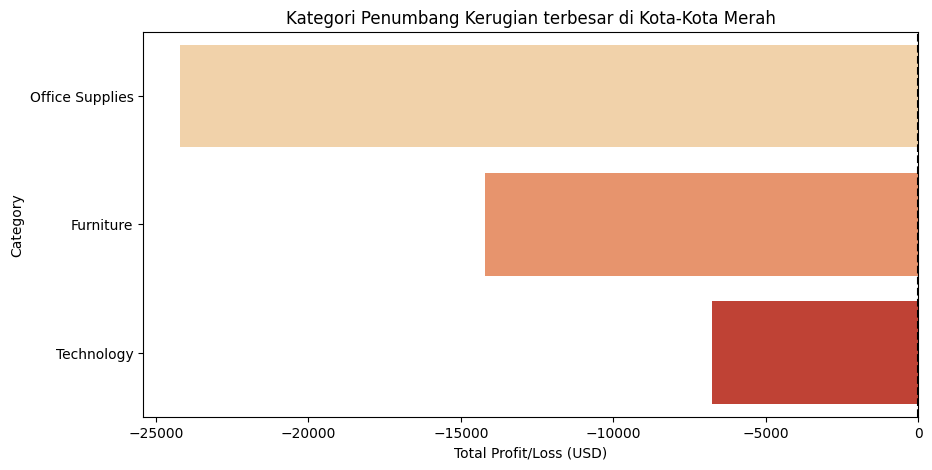

In [46]:
plt.figure(figsize=(10,5))
sns.barplot(x=kategori_rugi.values, y=kategori_rugi.index, palette='OrRd')

plt.title("Kategori Penumbang Kerugian terbesar di Kota-Kota Merah", fontsize=12)
plt.xlabel("Total Profit/Loss (USD)")
plt.ylabel('Category')
plt.axvline(0, color='black', linestyle='--')
plt.show()

Office Supplies adalah kategori yang menyumbang kerugian terbesar

In [52]:
df_office_rugi = df_rugi[df_rugi['Category'] == 'Office Supplies']
print(df_office_rugi.groupby('Sub-Category')[['Profit', 'Discount']].mean())

                 Profit  Discount
Sub-Category                     
Appliances   -93.741172  0.575000
Art            3.603036  0.200000
Binders      -91.625133  0.747685
Envelopes     26.240415  0.200000
Fasteners      3.510752  0.193939
Labels         7.482233  0.200000
Paper         17.267248  0.200000
Storage      -14.552078  0.200000
Supplies     -71.147925  0.200000


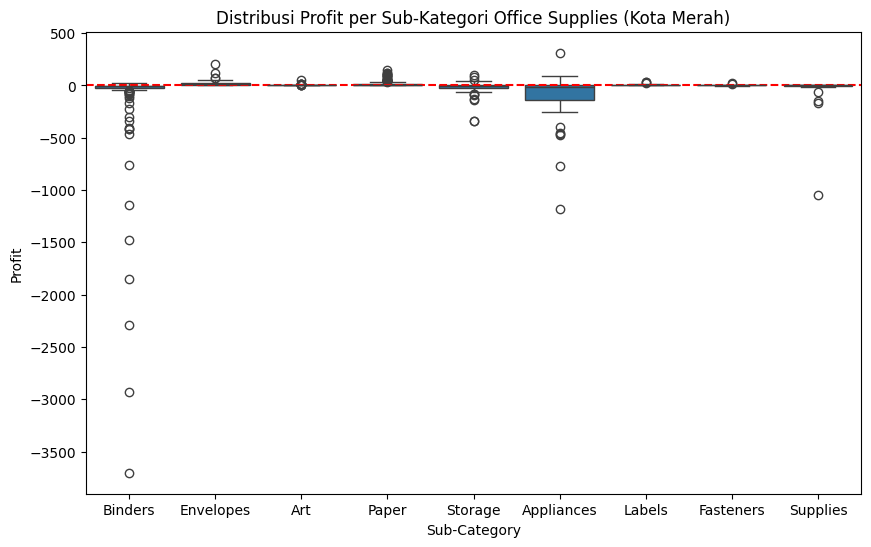

In [53]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Sub-Category', y='Profit', data=df_office_rugi)
plt.title("Distribusi Profit per Sub-Kategori Office Supplies (Kota Merah)")
plt.axhline(0, color='red', linestyle="--")
plt.show()

# DEEP ANALYSIS



### CEK KORELASI ANTARA DISKON, SALES, DAN PROFIT

In [42]:
sales_corr = df[['Sales', 'Discount', 'Profit']].corr()
print(sales_corr)

             Sales  Discount    Profit
Sales     1.000000 -0.028190  0.479064
Discount -0.028190  1.000000 -0.219487
Profit    0.479064 -0.219487  1.000000
